# Analyse du système de balle sur poutre

In [1]:
## importations ne pas modifier

from Models.BallBeam import ballbeam_config
from Models.BallBeam.StateSpace import LinearStateSpaceModel
from Models.BallBeam.TransferFunctions import TransferFunctionModel
from Models.BallBeam.NonlinearDynamics import NonlinearBallBeamModel

from Simulation.simulation import TFSimulator
from Simulation.simulation import HybridSim
from Simulation.simulation import NonLinearHybridSim

from Simulation.runners import *

from Metrics_Plotting.SimLog import SimLog
from Metrics_Plotting.Plotting import Plotting
from Metrics_Plotting.Metrics import Metrics

from Control.DiscretePID import DiscretePID
from Control.RSTController import RSTController

from Utils import computeRST
from Utils import utils

import numpy as np
import control as ct
import matplotlib.pyplot as plt

%matplotlib inline

Dans un notebook Jupyter, les cellules doivent généralement être exécutées dans l'ordre où elles apparaissent. En effet, certaines cellules définissent des variables, des fonctions ou des paramètres qui sont utilisés par les cellules suivantes.

Si une cellule est exécutée avant celles dont elle dépend, des erreurs peuvent apparaître car certaines données ne seront pas encore disponibles en mémoire. Il est donc recommandé de commencer par la première cellule du notebook et de progresser séquentiellement jusqu'à la dernière. Lorsqu'une cellule est modifiée, il peut être nécessaire de réexécuter les cellules qui suivent afin de mettre à jour les résultats.

Pour repartir d'un état propre, il est possible de redémarrer le noyau d'exécution (kernel) puis d'exécuter à nouveau toutes les cellules dans l'ordre. Cette pratique permet de vérifier que le notebook fonctionne correctement et que tous les résultats peuvent être reproduits à partir d'une session vierge.

Pour exécuter toutes les cellules dans l'ordre descendant, cliquer sur Run → Run all cells.

Pour redémarrer le noyau, cliquer sur Kernel → Restart Kernel.

### Configuration de la simulation :

$T$ est le temps total de simulation et $dt$ est la période d'échantillonnage du correcteur.

In [2]:
ballbeam_config.T=1  #sec
ballbeam_config.dt=0.05 #sec

##### Questions :
- Quelle est la fréquence d'échantillonnage $f_e = 1/dt$ en Hz ?
- Combien d'instants de simulation $N = T/dt$ y aura-t-il ?

##### Initialisation des simulateurs
Dans cette partie, on crée les instances de classes nécessaires à la simulation de la réponse indicielle et impulsionnelle.

In [3]:
X_0 = np.array([[0.0],[0]])                                        # État initial
double_int_TF = TransferFunctionModel(ballbeam_config)             # Instance de TransferFunctionModel           
double_int_SS = LinearStateSpaceModel(ballbeam_config)             # Modèle dans l'espace des états 
double_int_sim_dis = TFSimulator(double_int_TF.Tf_dis, X_0)        # Simulateur de fonctions de transfert discrètes
double_int_sim_continu = HybridSim(double_int_SS, ballbeam_config) # Simulateur continu dans l'espace des états

##### Questions :
- Que représentent les deux composantes de l'état initial $X_0 = [[0], [0]]$ physiquement?

- Pourquoi utilise-t-on deux simulateurs différents pour représenter le même système ?

### Réponse Impulsionnelle discrète et continue

Avant d'enregistrer la réponse impulsionnelle, on initialise des enregistreurs (Log_Impuls) qui contiennent trois listes vides :

t_hist[] (le temps), u_hist[] (la commande), y_hist[] (la sortie).

In [4]:
Log_Impuls_Discret=SimLog()
Log_Impuls_Continu=SimLog()


#### Simulation

In [5]:
y0=0.0
## Simulation discrète
Log_Impuls_Discret=run_discrete_impulse_response(double_int_sim_dis,ballbeam_config,y0,Log_Impuls_Discret)
## Simulation continue
Log_Impuls_Continu=run_continuous_impulse_response(double_int_sim_continu,X_0,Log_Impuls_Continu)

À la fin de la simulation, Log_Impuls_Discret contient les listes remplies avec les données :

In [6]:
print(Log_Impuls_Discret.t_hist[0:5]) ## 5 premières valeurs de t_hist


[0, 0.05, 0.1, 0.15000000000000002, 0.2]


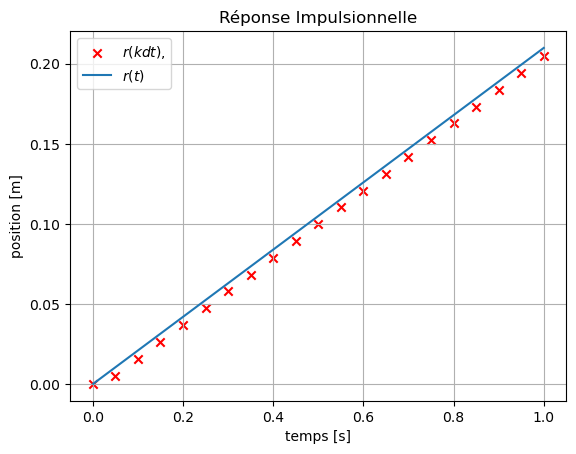

In [7]:
## Affichage — ne pas modifier 
plt.figure()
plt.title('Réponse Impulsionnelle')
plt.xlabel('temps [s]')
plt.ylabel('position [m]')
plt.scatter(Log_Impuls_Discret.t_hist,Log_Impuls_Discret.y_hist,label='$r(kdt)$,',marker='x',color='red')
plt.plot(Log_Impuls_Continu.t_hist,Log_Impuls_Continu.y_hist,label='$r(t)$')
plt.legend()
plt.grid()
## Décommenter pour enregistrer la figure 
#plt.savefig('ReponseImpulsionnelle_DoubleInt.jpg')
plt.show()

##### Questions :
- Y a-t-il un écart visible entre les croix rouges (discret) et la courbe bleue (continu) ? Dans quel sens ?
- Que se passerait-il sur cet écart si l'on réduisait $dt$ ?

Le simulateur discret calcule la réponse à chaque instant $k \cdot dt$.

Le retard entre la réponse discrète et la réponse continue est une conséquence de la discrétisation de l'impulsion $\delta(t)$. En réduisant $dt$, le retard disparaît.

##### Questions :
- Calculer la fonction de transfert $\frac{R(s)}{\Theta(s)}$ à partir de l'expression $\frac{d^2r(t)}{dt^2}=K\theta(t)$.

- L'allure de la réponse impulsionnelle est-elle cohérente avec la fonction de transfert ? Pourquoi ?

### Réponse Indicielle discrète et continue

Comme pour la réponse impulsionnelle, on initialise des enregistreurs (Log_Indic) qui vont stocker les données de la simulation :

t_hist[] (le temps), u_hist[] (la commande), y_hist[] (la sortie).

In [8]:
Log_Indic_Discret=SimLog()
Log_Indic_Continu=SimLog()

#### Simulation

In [9]:
## Simulation discrète
Log_Indic_Discret=run_discrete_step_response(double_int_sim_dis,ballbeam_config,y0,Log_Indic_Discret)
## Simulation continue
Log_Indic_Continu=run_continuous_step_response(double_int_sim_continu,X_0,Log_Indic_Continu)

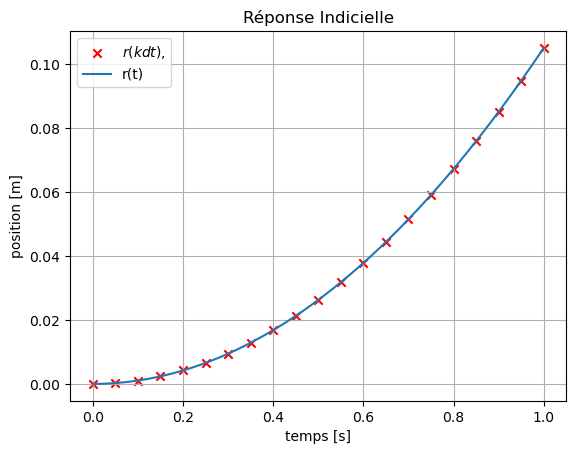

In [10]:
## Affichage — ne pas modifier 
plt.figure()
plt.title('Réponse Indicielle')
plt.xlabel('temps [s]')
plt.ylabel('position [m]')
plt.scatter(Log_Indic_Discret.t_hist,Log_Indic_Discret.y_hist,label='$r(kdt)$,',marker='x',color='red')
plt.plot(Log_Indic_Continu.t_hist,Log_Indic_Continu.y_hist,label='r(t)')
plt.legend()
plt.grid()
## Décommenter pour enregistrer la figure 
#plt.savefig('ReponseIndicielle_DoubleInt.jpg')
plt.show()

##### Questions :
- Les points discrets (croix rouges) coïncident-ils avec la courbe continue aux instants $k \cdot dt$ ?
- Comparer visuellement avec la réponse impulsionnelle : quelle différence observe-t-on concernant l'écart entre discret et continu ?

Contrairement à la réponse impulsionnelle, la réponse indicielle discrète coïncide exactement avec la réponse continue aux instants d'échantillonnage $k \cdot dt$. Il n'y a donc pas de retard visible entre les deux courbes. Cette propriété est une conséquence directe de la discrétisation par bloqueur d'ordre zéro (ZOH), qui garantit l'égalité des deux réponses à chaque période $dt$.

##### Questions :
- Calculer $R_{\Gamma}(s)$, la réponse de la sortie à l'échelon.

- Le résultat est-il cohérent avec la courbe affichée ci-dessus ?

- Conclure sur la stabilité du système (expliciter les pôles et les zéros de la fonction de transfert continue).